# Phase 4C — Cost-aware optimization and expected-return regularization

This notebook reads the versioned `phase4c_results.json`; it does not refit the 14-strategy
comparison. It tests how shrinkage, rank transforms and turnover penalties change gross return,
net return and turnover. The released result is negative: no Phase 4C variant displaces the
classical hurdle on either universe. That makes the lever diagnosis useful, but not evidence of
ML added value.

> **Actualisation sûre — release MAD/BAM (2026-08-09).** Ce notebook est exécuté sur
> les artefacts finaux versionnés. `full_2021` est exprimé en **MAD**, avec conversion
> causale des niveaux de prix ETF au taux de référence officiel Bank Al-Maghrib, sans
> couverture de change. `etf_2017` est un univers composé uniquement d'ETF en **USD**,
> commence en novembre 2004 et n'est pas modifié par cette correction. Les niveaux de
> Sharpe des deux univers ne sont donc pas comparés entre eux. Les écarts ponctuels sont
> descriptifs; le livrable est un prototype de recherche, ni un conseil, ni un système
> déployé.

In [1]:
from pathlib import Path
import json

SAFE_ROOT = Path.cwd()
if not (SAFE_ROOT / "data" / "gold").exists():
    SAFE_ROOT = SAFE_ROOT.parent
GOLD_RELEASE = SAFE_ROOT / "data" / "gold"

snapshot = json.loads((GOLD_RELEASE / "snapshot_manifest.json").read_text())
currency = json.loads((GOLD_RELEASE / "currency_manifest.json").read_text())
assert snapshot["git_dirty"] is False, "The published snapshot itself must have clean provenance."
assert currency["universes"]["full_2021"]["base_currency"] == "MAD"
assert currency["universes"]["etf_2017"]["base_currency"] == "USD"
print("Published snapshot:", snapshot["git_commit"][:12])
print("full_2021: MAD, official BAM FX, unhedged")
print("etf_2017: USD-only, FX correction not applicable")

Published snapshot: ae87f48207d1
full_2021: MAD, official BAM FX, unhedged
etf_2017: USD-only, FX correction not applicable


## 1. Setup — load the committed Phase 4C artifact (P4)

In [2]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NB_CWD = Path.cwd()
ROOT = NB_CWD.parent if (NB_CWD.parent / "data").exists() else NB_CWD
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RESULTS = json.loads((ROOT / "data" / "gold" / "phase4c_results.json").read_text())

PHASE4C = {"rf_signal_cost", "rf_signal_shrunk", "rf_signal_rank",
           "rf_signal_cost_dcc", "xgb_signal_cost"}
BASELINE_SIGNALS = {"rf_signal", "xgb_signal"}   # the Phase 4B floor

for uni, entry in RESULTS.items():
    h = entry["phase4_hurdle"]
    print(f"{uni}: {entry['n_trials']} strategies, OOS {entry['oos_start']} -> {entry['oos_end']}")
    print(f"   Phase 4 hurdle: {h['strategy']} @ {h['sharpe_net']:.4f}   "
          f"| best this run: {entry['strategy']} @ {entry['sharpe_net']:.4f} "
          f"(above hurdle: {entry['beats_phase4_hurdle']})")

etf_2017: 14 strategies, OOS 2005-12-01 -> 2026-07-24
   Phase 4 hurdle: min_variance @ 0.9525   | best this run: min_variance @ 0.9525 (above hurdle: False)
full_2021: 14 strategies, OOS 2022-08-01 -> 2026-07-24
   Phase 4 hurdle: max_sharpe @ 1.0690   | best this run: max_sharpe @ 1.0690 (above hurdle: False)


## 2. The full scoreboard — 14 strategies, ranked by net Sharpe (P1, P4)

The Phase 4C variants (★) sit *inside* the same shared trial pool as the 9 strategies carried
forward from Phase 4B, so the comparison and the DSR accounting stay honest.

In [3]:
def scoreboard(universe: str) -> pd.DataFrame:
    entry = RESULTS[universe]
    rows = []
    for name, m in entry["per_strategy"].items():
        tag = "phase4c" if name in PHASE4C else ("phase4b_signal" if name in BASELINE_SIGNALS else "prior")
        rows.append({
            "strategy": name,
            "sharpe_gross": m["sharpe_gross"],
            "sharpe_net": m["sharpe_net"],
            "cost_drag": round(m["sharpe_gross"] - m["sharpe_net"], 4),
            "avg_turnover": m["avg_turnover"],
            "group": tag,
        })
    df = pd.DataFrame(rows).sort_values("sharpe_net", ascending=False).set_index("strategy")
    return df

full_board = scoreboard("full_2021")
full_board

,sharpe_gross,sharpe_net,cost_drag,avg_turnover,group
strategy,,,,,
max_sharpe,1.1036,1.0690,0.0346,0.1444,prior
dcc_garch,1.1573,1.0526,0.1047,0.3781,prior
rf_signal_cost_dcc,1.0727,1.0097,0.0630,0.2981,phase4c
min_variance_ewma,1.0361,0.9855,0.0506,0.2079,prior
rf_signal_cost,1.0305,0.9683,0.0622,0.3064,phase4c
rf_signal_shrunk,1.0888,0.9578,0.1310,0.6285,phase4c
regime_conditional,1.0368,0.9571,0.0797,0.3212,prior
equal_weight,0.9647,0.9528,0.0119,0.0528,prior
xgb_signal_cost,1.0573,0.9419,0.1154,0.5548,phase4c


In [4]:
HURDLE = {u: RESULTS[u]["phase4_hurdle"]["sharpe_net"] for u in RESULTS}
print(f"full_2021 Phase 4 hurdle (regime_conditional): {HURDLE['full_2021']:.4f}")
print(f"etf_2017  Phase 4 hurdle (max_sharpe):         {HURDLE['etf_2017']:.4f}")
print()
for uni in RESULTS:
    best = RESULTS[uni]
    print(f"{uni}: best net Sharpe {best['sharpe_net']:.4f} by {best['strategy']} "
          f"-- {'ABOVE' if best['beats_phase4_hurdle'] else 'is not above'} the hurdle")

full_2021 Phase 4 hurdle (regime_conditional): 1.0690
etf_2017  Phase 4 hurdle (max_sharpe):         0.9525

etf_2017: best net Sharpe 0.9525 by min_variance -- is not above the hurdle
full_2021: best net Sharpe 1.0690 by max_sharpe -- is not above the hurdle


## 3. The turnover ↔ Sharpe trade-off, made visible (P1)

Phase 4C is entirely about one trade-off: a signal's *gross* merit versus the *cost of acting on
it*. The scatter puts every strategy in that plane — net Sharpe against average turnover — so the
story reads off the geometry. The Phase 4B `rf_signal` (high turnover, good-but-eroded net) and its
Phase 4C descendants are highlighted; the dashed line is the hurdle every point is chasing.

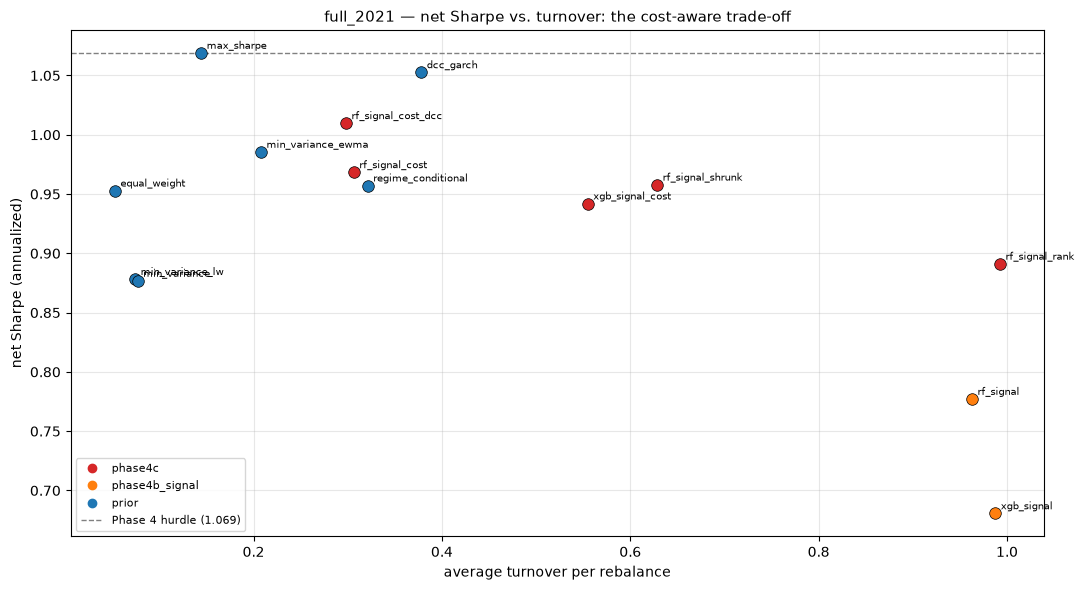

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
board = scoreboard("full_2021")
colors = {"phase4c": "tab:red", "phase4b_signal": "tab:orange", "prior": "tab:blue"}
for name, row in board.iterrows():
    ax.scatter(row["avg_turnover"], row["sharpe_net"],
               color=colors[row["group"]], s=70, zorder=3,
               edgecolor="black", linewidth=0.5)
    ax.annotate(name, (row["avg_turnover"], row["sharpe_net"]),
                fontsize=7.5, xytext=(4, 3), textcoords="offset points")
ax.axhline(HURDLE["full_2021"], ls="--", color="gray", lw=1,
           label=f"Phase 4 hurdle ({HURDLE['full_2021']:.3f})")
ax.set_xlabel("average turnover per rebalance"); ax.set_ylabel("net Sharpe (annualized)")
ax.set_title("full_2021 — net Sharpe vs. turnover: the cost-aware trade-off", fontsize=11)
handles = [plt.Line2D([0], [0], marker="o", ls="", color=c, label=g)
           for g, c in colors.items()]
ax.legend(handles=handles + [ax.lines[0]], fontsize=8, loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Reading the geometry:** `rf_signal_shrunk` moves up-and-left from `rf_signal` — *less* turnover
*and* higher net Sharpe, landing a hair below the hurdle. `rf_signal_cost` moves far left but also
sharply *down* — the penalty bought low turnover at the cost of the signal itself. Those two
opposite trajectories from the same starting point are the whole finding, quantified next.

## 4. Which lever worked, and why the penalty backfired (P1)

Each Phase 4C variant changed exactly one thing relative to `rf_signal` (except the deliberate
`_cost_dcc` combination), so its effect is attributable. Comparing each against the `rf_signal`
baseline isolates the lever.

In [6]:
def delta_vs_baseline(universe: str) -> pd.DataFrame:
    ps = RESULTS[universe]["per_strategy"]
    base = ps["rf_signal"]
    rows = []
    for name in ["rf_signal_shrunk", "rf_signal_rank", "rf_signal_cost", "rf_signal_cost_dcc"]:
        m = ps[name]
        rows.append({
            "variant": name,
            "d_gross": round(m["sharpe_gross"] - base["sharpe_gross"], 3),
            "d_net": round(m["sharpe_net"] - base["sharpe_net"], 3),
            "d_turnover": round(m["avg_turnover"] - base["avg_turnover"], 3),
            "net": m["sharpe_net"],
        })
    df = pd.DataFrame(rows).set_index("variant")
    return df

print("full_2021 — change vs. the current rf_signal baseline:")
delta_vs_baseline("full_2021")

full_2021 — change vs. the current rf_signal baseline:


,d_gross,d_net,d_turnover,net
variant,,,,
rf_signal_shrunk,0.1270,0.1810,-0.3340,0.9578
rf_signal_rank,0.1150,0.1140,0.0300,0.8911
rf_signal_cost,0.0680,0.1910,-0.6560,0.9683
rf_signal_cost_dcc,0.1110,0.2330,-0.6650,1.0097


In [7]:
# The XGBoost asymmetry: the SAME penalty helped the over-trader and hurt the good model.
ps = RESULTS["full_2021"]["per_strategy"]
print("The turnover penalty's OPPOSITE effect on two models (full_2021):")
print(f"  rf_signal  (was good): net {ps['rf_signal']['sharpe_net']:.3f} @ turnover "
      f"{ps['rf_signal']['avg_turnover']:.3f}  ->  rf_signal_cost: "
      f"net {ps['rf_signal_cost']['sharpe_net']:.3f} @ turnover {ps['rf_signal_cost']['avg_turnover']:.3f}")
print(f"  xgb_signal (over-traded): net {ps['xgb_signal']['sharpe_net']:.3f} @ turnover "
      f"{ps['xgb_signal']['avg_turnover']:.3f}  ->  xgb_signal_cost: "
      f"net {ps['xgb_signal_cost']['sharpe_net']:.3f} @ turnover {ps['xgb_signal_cost']['avg_turnover']:.3f}")

The turnover penalty's OPPOSITE effect on two models (full_2021):
  rf_signal  (was good): net 0.777 @ turnover 0.963  ->  rf_signal_cost: net 0.968 @ turnover 0.306
  xgb_signal (over-traded): net 0.681 @ turnover 0.988  ->  xgb_signal_cost: net 0.942 @ turnover 0.555


**How to read the levers.** Shrinkage and turnover penalties change the trade-off, but their
effects are model-specific. A penalty can reduce turnover while destroying the gross signal; a
shrinkage transform can improve a challenger without clearing the released hurdle. These are
mechanical observations from fixed configurations, not tuned economic conclusions.

## 5. Gross → net cost decomposition (P1)

The bar chart separates each signal strategy's *gross* skill from the *cost drag* that turnover
imposes — the single clearest picture of where Phase 4B's value leaked and which lever plugged it.

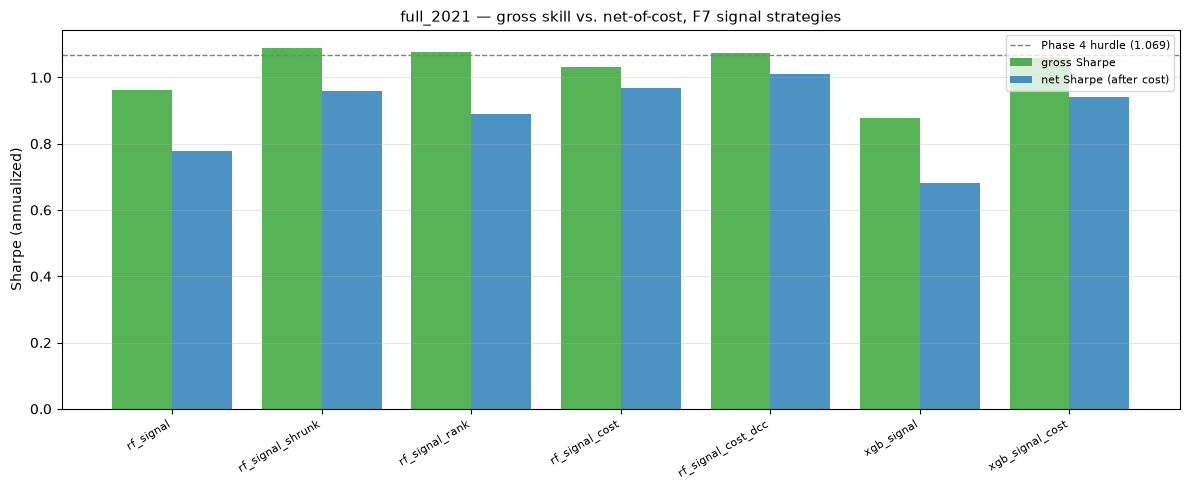

In [8]:
order = ["rf_signal", "rf_signal_shrunk", "rf_signal_rank",
         "rf_signal_cost", "rf_signal_cost_dcc", "xgb_signal", "xgb_signal_cost"]
ps = RESULTS["full_2021"]["per_strategy"]
gross = [ps[n]["sharpe_gross"] for n in order]
net = [ps[n]["sharpe_net"] for n in order]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(order))
ax.bar(x - 0.2, gross, 0.4, label="gross Sharpe", color="tab:green", alpha=0.8)
ax.bar(x + 0.2, net, 0.4, label="net Sharpe (after cost)", color="tab:blue", alpha=0.8)
ax.axhline(HURDLE["full_2021"], ls="--", color="gray", lw=1,
           label=f"Phase 4 hurdle ({HURDLE['full_2021']:.3f})")
ax.set_xticks(x); ax.set_xticklabels(order, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Sharpe (annualized)")
ax.set_title("full_2021 — gross skill vs. net-of-cost, F7 signal strategies", fontsize=11)
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

The green/blue gap *is* the transaction cost. `rf_signal` has the tallest green bar and one of the
widest gaps; `rf_signal_shrunk` keeps the green bar nearly as tall while closing most of the gap.
`rf_signal_cost` closes the gap almost entirely — but only by shrinking the green bar itself, which
is the wrong way to reduce cost drag.

## 6. `etf_2017` — same levers on the USD-only deep-history universe

This five-ETF universe begins in November 2004. Its 25% cap is near-determining, so changes in
expected-return modelling have limited room to alter allocations. The table is still reported;
the constraint caveat prevents interpreting a negative challenger result as a universal statement
about ML.

In [9]:
etf_board = scoreboard("etf_2017").head(8)
etf_board[["sharpe_gross", "sharpe_net", "avg_turnover", "group"]]

,sharpe_gross,sharpe_net,avg_turnover,group
strategy,,,,
min_variance,0.9559,0.9525,0.0318,prior
min_variance_lw,0.9559,0.9525,0.0318,prior
regime_conditional,0.9428,0.9371,0.0561,prior
max_sharpe,0.9156,0.9120,0.0380,prior
rf_signal_shrunk,0.9192,0.9073,0.1199,phase4c
rf_signal,0.9164,0.9040,0.1266,phase4b_signal
min_variance_ewma,0.9009,0.8942,0.0613,prior
rf_signal_cost_dcc,0.8988,0.8931,0.0588,phase4c


The canonical table above determines the current ranking. No Phase 4C challenger displaces the released classical hurdle on this universe.

## 7. Summary — final release

No Phase 4C variant displaces the classical hurdle on either universe. The useful contribution is
the diagnosis: expected-return regularization and transaction-cost penalties affect RF and XGB
differently, so a single global lever is not defensible. Later forward-only selection and the
240-candidate White/SPA correction do not establish challenger outperformance.